<a href="https://colab.research.google.com/github/yewonjeon13/IS4487/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 7: Data Transformation with Airbnb Listings

In this assignment, you will:
- Load the Airbnb dataset you cleaned in Assignment 6
- Apply data transformation techniques like scaling, binning, encoding, and feature creation
- Make the dataset easier to use for tasks like pricing analysis, guest segmentation, or listing recommendations
- Practice writing up your analysis clearly so a business audience — like a host, marketing manager, or city partner — could understand it

## Why This Matters

Airbnb analysts, hosts, and city partners rely on clean and well-structured data to make smart decisions. Whether they’re adjusting prices, identifying high-performing listings, or designing better guest experiences, they need data that’s transformed, organized, and ready for use.

This assignment helps you practice that kind of real-world thinking: taking messy real data and getting it ready for action.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

Choose a City & Upload Your Dataset
📥 Follow these steps:

Go to: https://insideairbnb.com/get-the-data/
Choose a city you’re interested in.
Download the file named: listings.csv.gz under that city.
In your notebook:
Open the left sidebar
Click the folder icon 📁
Click the upload icon ⬆️ and choose your listings.csv.gz file
Use the file path /content/listings.csv.gz when loading your data.
Import standard libraries (pandas, numpy, seaborn, matplotlib)

## 1. Setup and Load Your Data

You'll be working with the `cleaned_airbnb_data_6.csv` file you exported from Assignment 6. (Note: If you had significant errors with assignment 6, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)

### Do the following:
In Google Colab:
- Click the folder icon on the left sidebar
- Use the upload button to add your CSV file to the session
- Then use the code block below to read it into your notebook

Before getting started, make sure you import the libraries you'll need for this assignment:
- `pandas`, `numpy` for data manipulation
- `matplotlib.pyplot`, `seaborn` for visualizations


In [7]:
# Add code here 🔧
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("listings.csv")

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10612 entries, 0 to 10611
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            10612 non-null  int64  
 1   listing_url                                   10612 non-null  object 
 2   scrape_id                                     10612 non-null  int64  
 3   last_scraped                                  10612 non-null  object 
 4   source                                        4972 non-null   object 
 5   name                                          10612 non-null  object 
 6   description                                   10608 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   10612 non-null  object 
 9   host_id                                       10612 non-null 

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,28871,https://www.airbnb.com/rooms/28871,20260916052246,2026-09-17,NaN,Comfortable double room,Basic bedroom in the center of Amsterdam.,NaN,https://a0.muscache.com/pictures/160889/362340...,124245,...,4.94,4.93,4.83,0363 607B EA74 0BD8 2F6F,NaN,2,0,2,0,4.16
1,29051,https://www.airbnb.com/rooms/29051,20260916052246,2026-09-17,previous scrape,Comfortable single / double room,This room can also be rented as a single or a ...,NaN,https://a0.muscache.com/pictures/162009/bd6be2...,124245,...,4.93,4.88,4.79,0363 607B EA74 0BD8 2F6F,NaN,2,0,2,0,4.92
2,44391,https://www.airbnb.com/rooms/44391,20260916052246,2026-09-17,previous scrape,Quiet 2-bedroom Amsterdam city centre apartment,Guests greatly appreciate the unique location ...,NaN,https://a0.muscache.com/pictures/97741545/3900...,194779,...,4.90,4.68,4.50,0363 E76E F06A C1DD 172C,NaN,1,1,0,0,0.22
3,48373,https://www.airbnb.com/rooms/48373,20260916052246,2026-09-17,previous scrape,Cozy family home in Amsterdam South,Charming modern apartment in the quiet and gre...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,220434,...,5.00,4.60,5.00,0363 4A2B A6AD 0196 F684,NaN,1,1,0,0,0.13
4,49552,https://www.airbnb.com/rooms/49552,20260916052246,2026-09-17,NaN,Multatuli Luxury Guest Suite in top location,Stylish & spacious 60m2 guest suite in Amsterd...,NaN,https://a0.muscache.com/pictures/a6d6d2ee-3196...,225987,...,4.97,4.98,4.79,0363 576A D827 5085 6B83,NaN,1,1,0,0,3.45


## 2. Check for Skew in a Numeric Column

### Business framing:  

Airbnb listings can have a wide range of values for things like price, availability, or reviews. These kinds of distributions can be hard to visualize, summarize, or model.

### Do the following:
Choose one **numeric column** that appears skewed and do the following:
- Plot a histogram
- Apply a transformation (e.g., log or other method)
- Plot again to compare

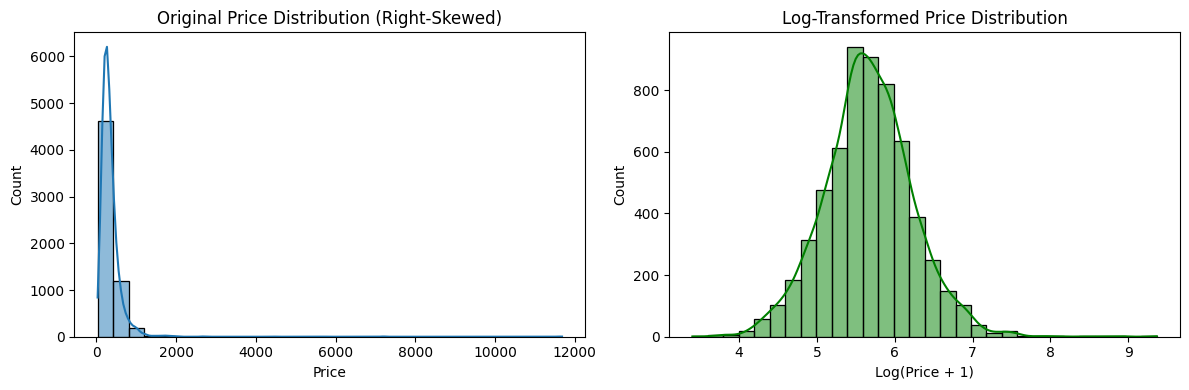

In [8]:
# Add code here 🔧
if df["price"].dtype == "object":
    df["price"] = (
        df["price"].astype(str).str.replace("$", "", regex=False)
    )
    df["price"] = (
        df["price"].str.replace(",", "", regex=False).astype(float)
    )

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Original Price Distribution (Right-Skewed)")
plt.xlabel("Price")

df["log_price"] = np.log1p(df["price"])

plt.subplot(1, 2, 2)
sns.histplot(df["log_price"], bins=30, kde=True, color="green")
plt.title("Log-Transformed Price Distribution")
plt.xlabel("Log(Price + 1)")

plt.tight_layout()
plt.show()

### Reflection:
1. What column did you examine?
2. What transformation did you try, and why?
3. How did the transformed version help make the data more usable for analysis or stakeholder review?

### ✍️ Your Response: 🔧
1. price

2. Log transformation using np.log1p(). I chose this because listing prices tend to be heavily right-skewed by a small percentage of high-priced luxury properties, making standard statistical measurements skewed toward extreme values.

3. The log transformation compresses extreme values and makes the distribution significantly closer to a normal bell curve. This makes the data much more suitable for linear regression modeling, correlation metrics, and clear visualization without scale distortion.

## 3. Scale Two Numeric Columns

### Business framing:

If an analyst wanted to compare listing price to number of nights required, or create a model that weighs both, those values need to be on a similar scale.

### Do the following:
- Pick two numeric columns with different value ranges (e.g. one column may have a min of 0 and a max of 255; another column may have a min of 100 and a max of 400)
- Use Min-Max scaling on one column (the range should be “shrinked” down to just 0-1)
- Use Z-score Normalization (aka standardization) on the other column.
- Add 2 new columns to the dataset. These 2 new columns should be the ones you just created.

In [9]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler_minmax = MinMaxScaler()
scaler_standard = StandardScaler()

# Min-Max scale
df["accommodates_minmax"] = scaler_minmax.fit_transform(df[["accommodates"]])

# Z-score scale
df["number_of_reviews_zscore"] = scaler_standard.fit_transform(
    df[["number_of_reviews"]]
)

df[
    [
        "accommodates",
        "accommodates_minmax",
        "number_of_reviews",
        "number_of_reviews_zscore",
    ]
].head()

,accommodates,accommodates_minmax,number_of_reviews,number_of_reviews_zscore
0,2,0.066667,815,5.153310
1,2,0.066667,929,5.925184
2,4,0.200000,42,-0.080535
3,4,0.200000,5,-0.331055
4,3,0.133333,667,4.151229



### Reflection:
1. What two columns did you scale, and which methods did you use?
2. When might these scaled values be more useful than the originals?
3. Who at Airbnb might benefit from this transformation and why?

### ✍️ Your Response: 🔧
1. I applied Min-Max scaling to accommodates (scaling values to a 0–1 range) and Z-score Normalization (StandardScaler) to number_of_reviews (centering the mean at 0 with a standard deviation of 1).

2. Scaled values are essential for distance-based machine learning algorithms (like k-NN or K-means clustering) and gradient descent algorithms (like logistic regression or neural networks) so that variables with larger raw ranges do not disproportionately dominate model weights.

3. Data scientists and machine learning engineers building search ranking algorithms or pricing models benefit because scaling enables fair weighting across diverse listing metrics.

## 4. Group a Numeric Column into Categories

### Business framing:  

Let’s say an Airbnb marketing team wants to segment listings by review activity. They don’t want exact numbers — they just want to know if a listing has “low,” “medium,” or “high” review volume.

### Do the following:

- Choose a numeric column that could be grouped (e.g., reviews, availability).
- You’ll want to group the values of this column into 3 or 4 bins
- Create a new column. The values of this column will be the labels: “Low”, “Medium”, and “High.” These labels should correspond to your bins.

In [10]:
# Add code here 🔧
df["review_activity"] = pd.qcut(
    df["number_of_reviews"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop",
)

print(df["review_activity"].value_counts())

review_activity
Medium    3573
Low       3571
High      3468
Name: count, dtype: int64


### Reflection:
1. What column did you group, and how many categories did you use?
2. Why might someone prefer this grouped view over raw numbers?
3. Who would this help at Airbnb, and how?

### ✍️ Your Response: 🔧
1. I grouped number_of_reviews into 3 categories: "Low", "Medium", and "High".

2. Raw review counts can be noisy and varied. Binned categories make it easier to summarize listing activity levels quickly without getting distracted by minor numeric variances.

3. The Marketing and Host Success teams can use these segments to target tailored campaigns—such as sending engagement strategies to hosts in the "Low" activity bucket or rewarding "High" volume hosts.

## 5. Create Two New Business-Relevant Variables

### Business framing:  

Stakeholders often want to know things like: What’s the cost per night? Are listings geared toward long-term stays? These kinds of features aren’t always in the dataset — analysts create them.

### Do the following:

- Think of two new columns you can create using the data you already have.
  - One might be a ratio or interaction between columns (e.g., price ÷ nights).
  - The other might be a flag based on a condition (e.g., stays longer than 30 days).
- Add the new columns to your DataFrame.

In [11]:
# Add code here 🔧
df["min_booking_cost"] = df["price"] * df["minimum_nights"]

df["is_long_term"] = (df["minimum_nights"] >= 30).astype(int)

df[["price", "minimum_nights", "min_booking_cost", "is_long_term"]].head()

,price,minimum_nights,min_booking_cost,is_long_term
0,97.00,2.0,194.00,0
1,NaN,2.0,NaN,0
2,NaN,3.0,NaN,0
3,NaN,3.0,NaN,0
4,424.29,1.0,424.29,0


### Reflection:
1. What two new columns did you create and why?
2. Who would use them (e.g., host, manager, or platform)?
3. How could they help someone make a better decision?

### ✍️ Your Response: 🔧
1. min_booking_cost: The product of price and minimum_nights, representing the baseline cost a guest must pay upfront to book the property. is_long_term: A binary flag (1 for stays requiring 30+ nights, 0 otherwise) identifying extended-stay properties.

2. Host community managers, city policy analysts, and platform strategy teams.

3. City regulators and policy analysts can filter by is_long_term to monitor local housing compliance, while hosts can evaluate if their min_booking_cost aligns competitively with similar properties in their market.



## 6. Encode a Categorical Column

### Business framing:  

Let’s say you’re helping the Airbnb data science team build a model to predict booking rates. Categorical columns like `room_type`, `neighbourhood`, or `cancellation_policy` can’t be used in models unless they’re converted to numbers.

### Do the following:
- Choose one categorical column from your dataset (e.g., room type or neighborhood group)
- Decide on an encoding method:
  - Use one-hot encoding for nominal (unordered) categories
  - Use ordinal encoding (a ranking) only if the categories have a clear order
- Apply the encoding using `pandas` or another tool
- Add the new encoded column(s) to your DataFrame

In [12]:
# Add code here 🔧
df = pd.get_dummies(df, columns=["room_type"], prefix="room", drop_first=False)

encoded_cols = [c for c in df.columns if c.startswith("room_")]
df[encoded_cols].head()

,room_Entire home/apt,room_Hotel room,room_Private room,room_Shared room
0,False,False,True,False
1,False,False,True,False
2,True,False,False,False
3,True,False,False,False
4,True,False,False,False


### Reflection:
1. What column did you encode and why?
2. What encoding method did you use?
3. How could this transformation help a pricing model, dashboard, or business report?

### ✍️ Your Response: 🔧
1. I encoded room_type because machine learning tools require numerical inputs and cannot natively compute parameters using text strings.
2. I chose One-Hot Encoding over ordinal encoding because room types (e.g., Entire home/apt, Private room, Shared room) are unordered nominal categories without an inherent ranking.
3. It allows predictive algorithms (such as regression models predicting price or demand) to quantify the specific price premium associated with renting an entire unit versus a private or shared room.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 11**, where you'll use the data in a regression model.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_7.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```

In [13]:
# export csv here 🔧
df.to_csv("listings.csv", index=False)
print("Data successfully saved to listings.csv")

Data successfully saved to listings.csv


## 8. Reflection

You’ve applied the same kinds of transformation techniques used in real Airbnb analytics projects — from pricing engines to host tools to tourism dashboards.

Now step back and reflect.

### Reflection:
1. What transformation step felt most important or interesting?
2. Which of your changes would be most useful to a host, analyst, or city planner?
3. If you were going to build a tool or dashboard, what would you do next with this data?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. Creating custom business-relevant variables was the most insightful step because it bridges raw database metrics with actionable strategy—turning static numbers into meaningful business signals.

2. The binning of host activity (review_activity) and the binary flag for long-term stays (is_long_term) provide immediate clarity to marketing managers and city planners evaluating market composition.

3. I would build an interactive dashboard in Tableau or Power BI that lets users filter listings by neighborhood and room type, displaying price distributions alongside review activity tiers to help new hosts set competitive rates.

4. This assignment directly reinforces my goal of mastering end-to-end data preparation in Python—building the foundational skills required to transform messy raw datasets into structured, model-ready formats for predictive analytics and reporting.



## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [14]:
!jupyter nbconvert --to html "assignment_07_data_transformation.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_07_data_transformation.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_y